# Data Exploration & Preprocessing

**Objective:** To perform a comprehensive analysis and preparation of the AEP hourly energy consumption data. This notebook will cover visualization, stationarity testing, data cleaning, transformations, time-based splitting, and feature engineering, creating a solid foundation for all subsequent modeling tasks.```

In [2]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
# Display all columns in pandas
pd.set_option('display.max_columns', None)


In [4]:
# --- Statsmodels & Scipy ---
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import boxcox

### ** Initial Data Loading and Preparation**

First, we load the data, convert the `Datetime` column to a proper datetime index, and sort it to ensure chronological order.

In [27]:
# Load the dataset
df = pd.read_csv('AEP_hourly.csv', index_col='Datetime', parse_dates=True)

# Sort the index
df = df.sort_index()

# Rename the column for easier access
df = df.rename(columns={'AEP_MW': 'energy_mw'})

print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Data Shape: (121273, 1)

First 5 Rows:
                     energy_mw
Datetime                      
2004-10-01 01:00:00    12379.0
2004-10-01 02:00:00    11935.0
2004-10-01 03:00:00    11692.0
2004-10-01 04:00:00    11597.0
2004-10-01 05:00:00    11681.0


## **In-depth Exploratory Data Analysis (EDA)**

We will visualize the data to understand its trends, multiple seasonality patterns, and volatility.


#### ** Overall Trend and Volatility**

Let's plot the entire series and its rolling standard deviation to see the long-term trend and changes in volatility. A 30-day rolling window will smooth out daily fluctuations and highlight yearly patterns.

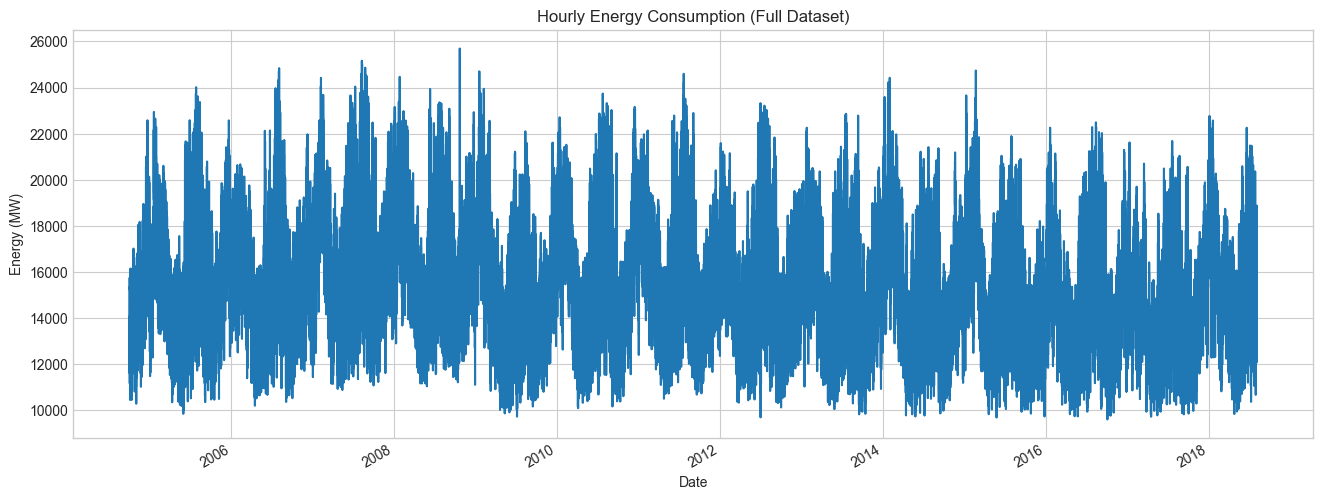

In [8]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(16, 6))
df['energy_mw'].plot(ax=ax, title='Hourly Energy Consumption (Full Dataset)')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
plt.show()


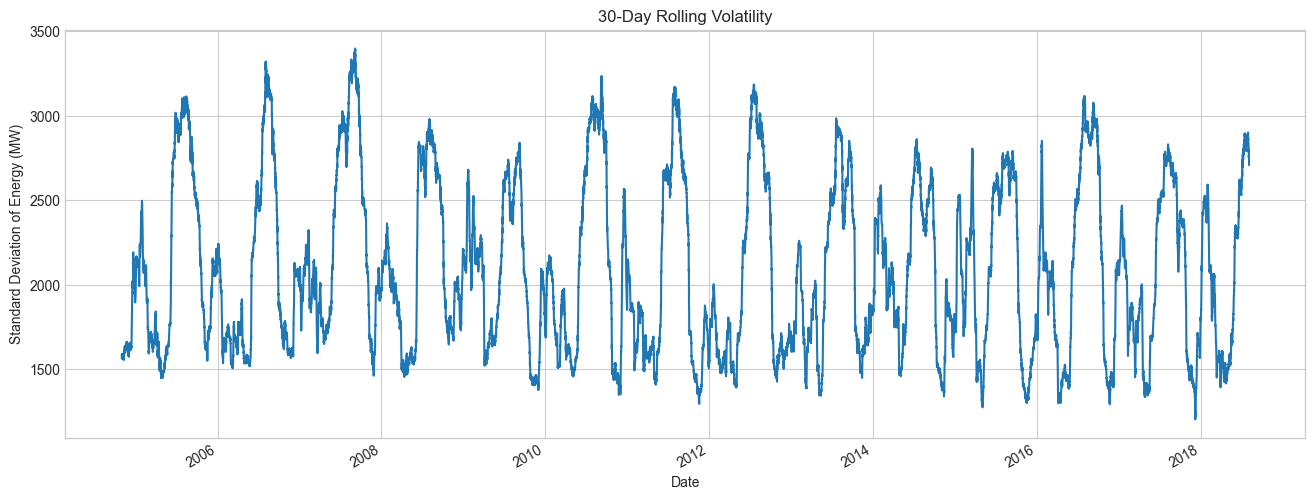

In [9]:

# Plot rolling volatility
rolling_std = df['energy_mw'].rolling(window=30*24).std() # 30-day rolling standard deviation
fig, ax = plt.subplots(figsize=(16, 6))
rolling_std.plot(ax=ax, title='30-Day Rolling Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Standard Deviation of Energy (MW)')
plt.show()

#### ** Visualization of Multiple Seasonality Patterns**
We can confirm the presence of yearly, weekly, and daily seasonality using boxplots

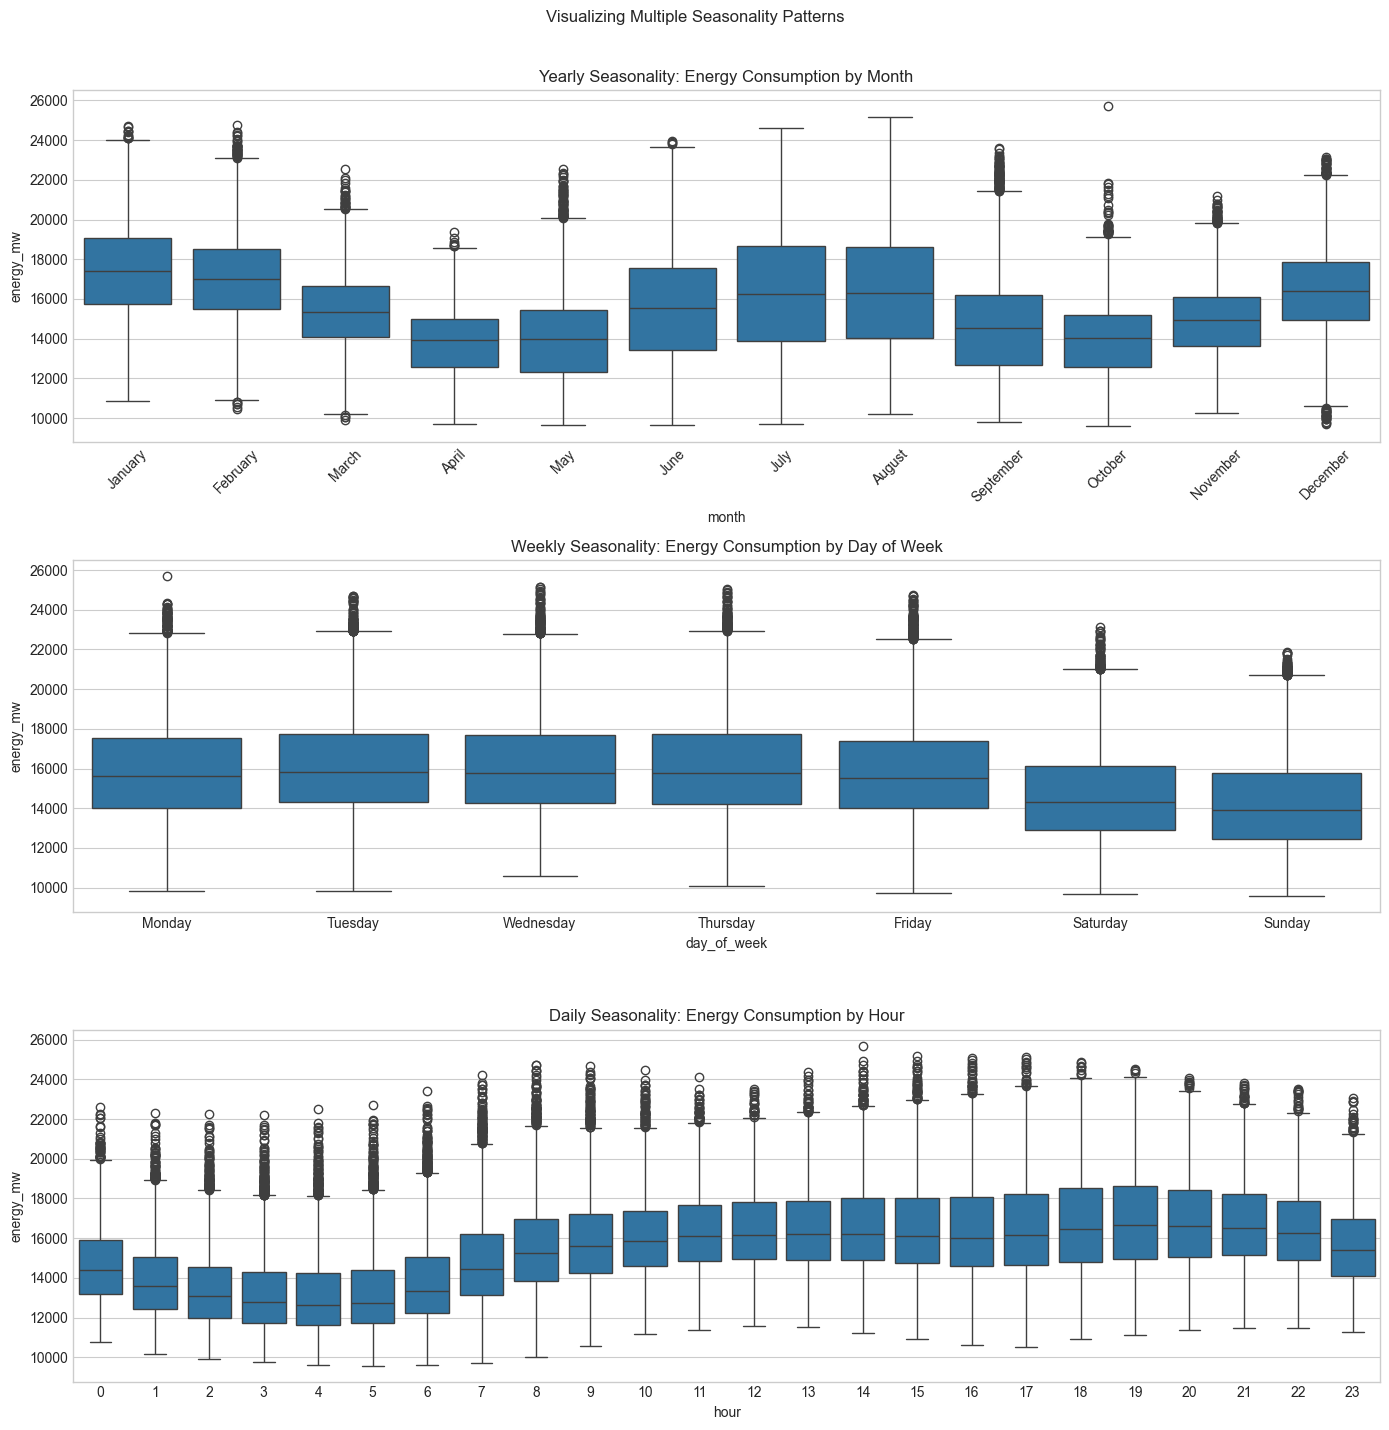

In [9]:
# Create new time-based features for plotting
df_plot = df.copy()
df_plot['year'] = df_plot.index.year
df_plot['month'] = df_plot.index.month_name()
df_plot['day_of_week'] = df_plot.index.day_name()
df_plot['hour'] = df_plot.index.hour

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharey=False)
fig.suptitle('Visualizing Multiple Seasonality Patterns')

# Yearly Seasonality (Month)
sns.boxplot(ax=axes[0], data=df_plot, x='month', y='energy_mw', order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
axes[0].set_title('Yearly Seasonality: Energy Consumption by Month')
axes[0].tick_params(axis='x', rotation=45)

# Weekly Seasonality (Day of Week)
sns.boxplot(ax=axes[1], data=df_plot, x='day_of_week', y='energy_mw', order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
axes[1].set_title('Weekly Seasonality: Energy Consumption by Day of Week')

# Daily Seasonality (Hour)
sns.boxplot(ax=axes[2], data=df_plot, x='hour', y='energy_mw')
axes[2].set_title('Daily Seasonality: Energy Consumption by Hour')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## **Stationarity Checks and Decomposition**

We will formally test for stationarity and decompose the series to isolate its components.

--- Stationarity Tests for Original Energy Series ---
ADF Test: p-value = 0.0000
Conclusion: Series is likely stationary.
--------------------


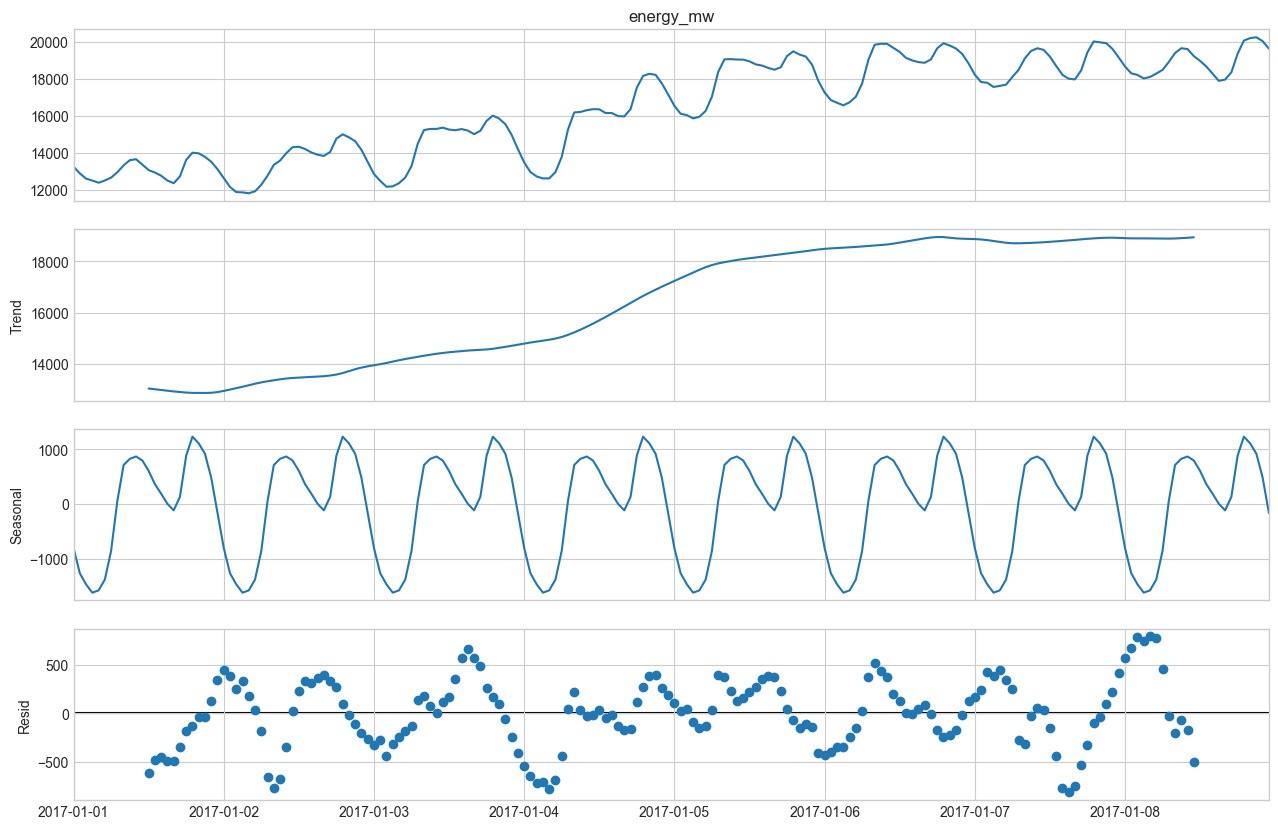

In [28]:
#Null Hypothesis (H0): The series has a unit root (non-stationary)
#Alternative Hypothesis (H1): The series is stationary
def stationarity_tests(series, series_name=''):
    """Performs and prints the results of ADF and KPSS stationarity tests.   """
    print(f"--- Stationarity Tests for {series_name} ---")
    adf_result = adfuller(series)
    print(f'ADF Test: p-value = {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05: print("Conclusion: Series is likely stationary.")
    else: print("Conclusion: Series is likely non-stationary.")
    print("-" * 20)

# Test the original series (using a sample for speed)
stationarity_tests(df['energy_mw'],'Original Energy Series')

# Decompose a week of data to visualize components
decomposition = seasonal_decompose(df['energy_mw']['2017-01-01':'2017-01-08'], model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.show()

## **Revisiting Stationarity Checks with a More Nuanced View**

Our initial ADF test gave a p-value of 0.0000, suggesting the series is stationary. This contradicts our visual analysis, which clearly shows strong seasonality. This paradox arises because the ADF test specifically looks for a *unit root* (a random, wandering trend), and our series, while non-stationary, has a *deterministic* seasonal pattern, not a unit root.

To get a clearer picture, we will use both the **ADF test** and the **KPSS test**.

*   **ADF Test:** Tests if the series has a unit root (H0: Non-stationary).
*   **KPSS Test:** Tests if the series is stationary around a constant or trend (H0: Stationary).

A common and powerful heuristic is:
- If ADF says "Stationary" and KPSS says "Non-Stationary", it's a strong sign the series is **Trend Stationary**.
- For practical modeling, **Trend Stationary still needs to be handled!**

In [17]:
from statsmodels.tsa.stattools import kpss

def stationarity_tests(series, series_name=''):
    print(f"--- Stationarity Tests for {series_name} ---")
    
    # ADF
    adf_result = adfuller(series)
    print(f'ADF Test: p-value = {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05:
        print("ADF Conclusion: Likely stationary (no unit root).")
    else:
        print("ADF Conclusion: Likely non-stationary (unit root present).")

    # KPSS
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f'KPSS Test: p-value = {kpss_result[1]:.4f}')
    if kpss_result[1] <= 0.05:
        print("KPSS Conclusion: Likely non-stationary.")
    else:
        print("KPSS Conclusion: Likely stationary.")
    
    print("-" * 40)

# Run on your series
stationarity_tests(df['energy_mw'], 'Original Energy Series')


--- Stationarity Tests for Original Energy Series ---
ADF Test: p-value = 0.0000
ADF Conclusion: Likely stationary (no unit root).
KPSS Test: p-value = 0.0100
KPSS Conclusion: Likely non-stationary.
----------------------------------------


C:\Users\Jesut\AppData\Local\Temp\ipykernel_27832\2230657691.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


## **Handling Missing Data, Outliers, and Transformations**

#### **Missing Data**
First, check for any missing values.

In [18]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


#### ** Outliers**

We can identify outliers using the Interquartile Range (IQR) method and "cap" them to reduce their influence without removing data points. A good way to do this for seasonal data is to first remove a seasonal component (like a weekly median) before calculating IQR.


In [29]:
# Outlier detection using IQR on a weekly cycle
weekly_median = df['energy_mw'].rolling(window=24*7).median()
detrended = df['energy_mw'] - weekly_median

Q1 = detrended.quantile(0.25)
Q3 = detrended.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = detrended[(detrended < lower_bound) | (detrended > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

# Capping the outliers by interpolating them
df['energy_mw_capped'] = df['energy_mw'].copy()
# Temporarily replace outliers with NaN to interpolate them based on surrounding values
df.loc[outliers.index, 'energy_mw_capped'] = np.nan
# Perform the interpolation and assign the result back to the column
df['energy_mw_capped'] = df['energy_mw_capped'].interpolate(method='time')

Number of outliers detected: 555


#### ** Data Transformations**

To stabilize the variance (as observed in the volatility plot), we can apply a transformation. The Box-Cox transformation is a powerful choice that includes the log transform as a special case.

Optimal Lambda for Box-Cox: 0.0578


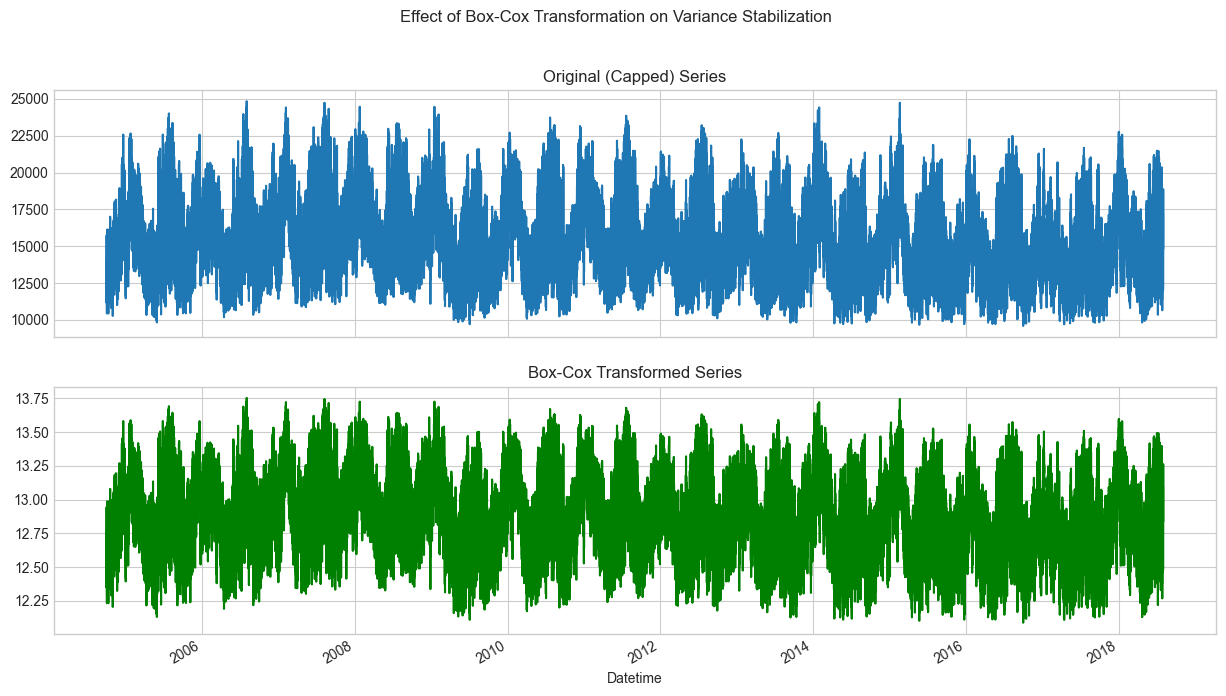

In [22]:
# Apply Box-Cox Transformation
# A small positive constant is added because Box-Cox requires positive data.
energy_positive = df['energy_mw_capped'] + 1e-6
transformed_data, lambda_boxcox = boxcox(energy_positive)
df['energy_mw_boxcox'] = transformed_data

print(f"Optimal Lambda for Box-Cox: {lambda_boxcox:.4f}")

# Visualize the effect
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
df['energy_mw_capped'].plot(ax=ax1, title='Original (Capped) Series')
df['energy_mw_boxcox'].plot(ax=ax2, title='Box-Cox Transformed Series', color='green')
plt.suptitle('Effect of Box-Cox Transformation on Variance Stabilization')
plt.show()

The transformed series shows much more stable variance over time, making it better suited for many forecasting models.

## **Time-Aware Train-Validation-Test Splits**

We must split the data chronologically to prevent data leakage. A standard split is 70% for training, 15% for validation, and 15% for testing.

Train set dates: 2004-10-01 01:00:00 to 2014-06-09 02:00:00 (Size: 84891)
Validation set dates: 2014-06-09 03:00:00 to 2016-07-06 01:00:00 (Size: 18191)
Test set dates: 2016-07-06 02:00:00 to 2018-08-03 00:00:00 (Size: 18191)


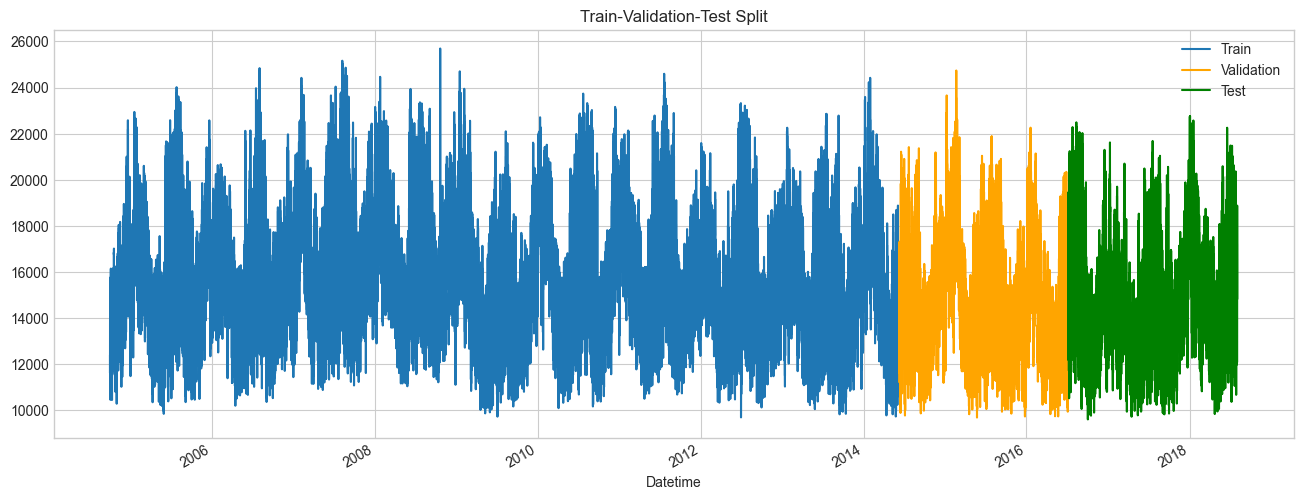

In [23]:
# Calculate split points
total_size = len(df)
train_end_idx = int(total_size * 0.70)
val_end_idx = int(total_size * 0.85)

# Create the splits
train_df = df.iloc[:train_end_idx]
val_df = df.iloc[train_end_idx:val_end_idx]
test_df = df.iloc[val_end_idx:]

print(f"Train set dates: {train_df.index.min()} to {train_df.index.max()} (Size: {len(train_df)})")
print(f"Validation set dates: {val_df.index.min()} to {val_df.index.max()} (Size: {len(val_df)})")
print(f"Test set dates: {test_df.index.min()} to {test_df.index.max()} (Size: {len(test_df)})")

# Plot the splits
fig, ax = plt.subplots(figsize=(16, 6))
train_df['energy_mw'].plot(ax=ax, label='Train')
val_df['energy_mw'].plot(ax=ax, label='Validation', color='orange')
test_df['energy_mw'].plot(ax=ax, label='Test', color='green')
ax.legend()
ax.set_title('Train-Validation-Test Split')
plt.show()

## **Generate Feature Engineering Pipelines**

We will now create a comprehensive feature engineering function that can be applied to any of our data splits. This function will generate lag features, rolling statistics, date/time encodings, and powerful Fourier terms to capture seasonality.

In [25]:
def create_features(df):
    """
    Creates a rich set of time series features from a datetime index.

    Args:
        df (pd.DataFrame): DataFrame with a datetime index.

    Returns:
        pd.DataFrame: DataFrame with new features added.
    """
    new_df = df.copy()

    # --- 1. Date/Time Encodings ---
    new_df['hour'] = new_df.index.hour
    new_df['dayofweek'] = new_df.index.dayofweek  # Monday=0, Sunday=6
    new_df['dayofyear'] = new_df.index.dayofyear
    new_df['weekofyear'] = new_df.index.isocalendar().week.astype(int)
    new_df['month'] = new_df.index.month
    new_df['year'] = new_df.index.year

    # --- 2. Lag Features ---
    # We use lags that capture recent values and seasonality.
    # Lags are created on the transformed data, as this can help linear models.
    lag_features = [1, 2, 3, 23, 24, 25, 47, 48, 49] # Recent hours and daily seasonality
    for lag in lag_features:
        new_df[f'lag_{lag}'] = new_df['energy_mw_boxcox'].shift(lag)

    # --- 3. Rolling Statistics ---
    # Use a 24-hour window to capture daily patterns.
    # Shift by 1 to prevent data leakage from the current hour.
    rolling_window = 24
    shifted_data = new_df['energy_mw_boxcox'].shift(1)
    new_df['rolling_mean_24h'] = shifted_data.rolling(window=rolling_window).mean()
    new_df['rolling_std_24h'] = shifted_data.rolling(window=rolling_window).std()

    # --- 4. Fourier Terms (for multiple seasonality) ---
    # A powerful way to model cycles without one-hot encoding.
    day_of_year = new_df.index.dayofyear
    year_length = 365.25 # Accounts for leap years

    # Yearly Seasonality
    new_df['sin_yearly'] = np.sin(2 * np.pi * day_of_year / year_length)
    new_df['cos_yearly'] = np.cos(2 * np.pi * day_of_year / year_length)

    # Daily Seasonality
    hour_of_day = new_df.index.hour
    new_df['sin_daily'] = np.sin(2 * np.pi * hour_of_day / 24)
    new_df['cos_daily'] = np.cos(2 * np.pi * hour_of_day / 24)

    return new_df.dropna() # Drop rows with NaNs created by lags/rolling stats

# Apply the feature engineering function to the full dataframe
df_featured = create_features(df)

print("Shape of the featured DataFrame:", df_featured.shape)
print("\nFeatured DataFrame Head:")
print(df_featured.head())


Shape of the featured DataFrame: (121224, 24)

Featured DataFrame Head:
                     energy_mw  energy_mw_capped  energy_mw_boxcox  hour  \
Datetime                                                                   
2004-10-03 02:00:00    10807.0           10807.0         12.294047     2   
2004-10-03 03:00:00    10600.0           10600.0         12.260982     3   
2004-10-03 04:00:00    10438.0           10438.0         12.234679     4   
2004-10-03 05:00:00    10430.0           10430.0         12.233370     5   
2004-10-03 06:00:00    10509.0           10509.0         12.246254     6   

                     dayofweek  dayofyear  weekofyear  month  year      lag_1  \
Datetime                                                                        
2004-10-03 02:00:00          6        277          40     10  2004  12.392027   
2004-10-03 03:00:00          6        277          40     10  2004  12.294047   
2004-10-03 04:00:00          6        277          40     10  2004  12.